In [41]:
import vrep 
import sys
import time 
import numpy as np
from tank import *
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [42]:
def parallel_zero_stage():
    distance_ES = ctrl.Antecedent(np.arange(0, 6, 0.01), 'distance_ES')
    distance_EN = ctrl.Antecedent(np.arange(0, 6, 0.01), 'distance_EN')
    speed = ctrl.Consequent(np.arange(-1, 8, 0.01), 'speed')

    distance_EN['poor'] = fuzz.trapmf(distance_EN.universe, [0, 0, 1.5, 1.55])
    distance_EN['average'] = fuzz.trapmf(distance_EN.universe, [1.5, 1.55, 2.5, 2.51])
    distance_EN['good'] = fuzz.trapmf(distance_EN.universe, [2.5, 2.51, 6, 6])

    distance_ES['poor'] = fuzz.trapmf(distance_ES.universe, [0, 0, 1.1, 2])
    distance_ES['good'] = fuzz.trapmf(distance_ES.universe, [1.1, 2, 6, 6])

    speed['zero'] = fuzz.trimf(speed.universe, [-1, 0, 1])
    speed['poor'] = fuzz.trimf(speed.universe, [0, 3, 5])
    speed['good'] = fuzz.trimf(speed.universe, [5, 6, 7])

    distance_EN.view()
    distance_ES.view()
    speed.view()

    rules = (
        ctrl.Rule(distance_EN['good'] & distance_ES['good'], speed['good']),
        ctrl.Rule(distance_EN['poor'] & distance_ES['poor'], speed['good']),
        ctrl.Rule(distance_EN['poor'] & distance_ES['good'], speed['good']),
        ctrl.Rule(distance_EN['good'] & distance_ES['poor'], speed['poor']),
        ctrl.Rule(distance_EN['average'] & distance_ES['good'], speed['poor']),
        ctrl.Rule(distance_EN['average'] & distance_ES['poor'], speed['zero']),
    )

    driving_ctrl = ctrl.ControlSystem(rules)
    driving_sim = ctrl.ControlSystemSimulation(driving_ctrl)

    return driving_sim

def parallel_first_stage():
    distance_ES = ctrl.Antecedent(np.arange(0, 6, 0.01), 'distance_ES')
    distance_SE = ctrl.Antecedent(np.arange(0, 6, 0.01), 'distance_SE')
    speed = ctrl.Consequent(np.arange(-1, 8, 0.01), 'speed')

    distance_SE['poor'] = fuzz.trapmf(distance_SE.universe, [0, 0, 2.4, 3])
    distance_SE['good'] = fuzz.trapmf(distance_SE.universe, [2.4, 3, 6, 6])

    distance_ES['poor'] = fuzz.trapmf(distance_ES.universe, [0, 0, 1.1, 2])
    distance_ES['good'] = fuzz.trapmf(distance_ES.universe, [1.1, 2, 6, 6])

    speed['zero'] = fuzz.trimf(speed.universe, [-1, 0, 1])
    speed['poor'] = fuzz.trimf(speed.universe, [0, 3, 5])
    speed['good'] = fuzz.trimf(speed.universe, [5, 6, 7])

    distance_ES.view()
    distance_SE.view()
    speed.view()

    rules = (
    ctrl.Rule(distance_SE['good'] & distance_ES['good'], speed['good']),
    ctrl.Rule(distance_SE['good'] & distance_ES['poor'], speed['zero']),
    ctrl.Rule(distance_SE['poor'] & distance_ES['good'], speed['poor']),
    ctrl.Rule(distance_SE['poor'] & distance_ES['poor'], speed['good'])
    )

    driving_ctrl = ctrl.ControlSystem(rules)
    driving_sim = ctrl.ControlSystemSimulation(driving_ctrl)

    return driving_sim

def parallel_second_stage():
    distance_ES_SE = ctrl.Antecedent(np.arange(0, 6, 0.01), 'distance_ES_SE')
    speed = ctrl.Consequent(np.arange(-1, 8, 0.01), 'speed')

    distance_ES_SE['poor'] = fuzz.trapmf(distance_ES_SE.universe, [0, 0, 0.79, 0.80])
    distance_ES_SE['good'] = fuzz.trapmf(distance_ES_SE.universe, [0.79, 0.80, 6, 6])

    speed['zero'] = fuzz.trimf(speed.universe, [-1, 0, 1])
    speed['poor'] = fuzz.trimf(speed.universe, [0, 1, 2])
    speed['good'] = fuzz.trimf(speed.universe, [5, 6, 7])

    distance_ES_SE.view()
    speed.view()

    rules = (
            ctrl.Rule(distance_ES_SE['good'], speed['good']),
            ctrl.Rule(distance_ES_SE['poor'], speed['zero']),
    )

    driving_ctrl = ctrl.ControlSystem(rules)
    driving_sim = ctrl.ControlSystemSimulation(driving_ctrl)

    return driving_sim

def parallel_third_stage():
    distance_SW_WS = ctrl.Antecedent(np.arange(0, 6, 0.01), 'distance_SW_WS')
    speed = ctrl.Consequent(np.arange(-1, 7, 0.01), 'speed')

    distance_SW_WS['poor'] = fuzz.trapmf(distance_SW_WS.universe, [0, 0, 1.1, 2])
    distance_SW_WS['good'] = fuzz.trapmf(distance_SW_WS.universe, [1.1, 2, 6, 6])

    speed['zero'] = fuzz.trimf(speed.universe, [-1, 0, 1])
    speed['poor'] = fuzz.trimf(speed.universe, [0, 1, 2])
    speed['good'] = fuzz.trimf(speed.universe, [5, 6, 7])

    distance_SW_WS.view()
    speed.view()

    rules = (
            ctrl.Rule(distance_SW_WS['good'], speed['good']),
            ctrl.Rule(distance_SW_WS['poor'], speed['zero']),
    )

    driving_ctrl = ctrl.ControlSystem(rules)
    driving_sim = ctrl.ControlSystemSimulation(driving_ctrl)

    return driving_sim

In [43]:
vrep.simxFinish(-1) # closes all opened connections, in case any prevoius wasnt finished
clientID=vrep.simxStart('127.0.0.1',19999,True,True,5000,5) # start a connection

if clientID!=-1:
    print ("Connected to remote API server")
else:
    print("Not connected to remote API server")
    sys.exit("Could not connect")

#create instance of Tank
tank=Tank(clientID)

Connected to remote API server


In [44]:
proximity_sensors=["EN","ES","NE","NW","SE","SW","WN","WS"]
proximity_sensors_handles=[0]*8

# get handle to proximity sensors
for i in range(len(proximity_sensors)):
    err_code,proximity_sensors_handles[i] = vrep.simxGetObjectHandle(clientID,"Proximity_sensor_"+proximity_sensors[i], vrep.simx_opmode_blocking)
    
#read and print values from proximity sensors
#first reading should be done with simx_opmode_streaming, further with simx_opmode_buffer parameter
for sensor_name, sensor_handle in zip(proximity_sensors,proximity_sensors_handles):
        err_code,detectionState,detectedPoint,detectedObjectHandle,detectedSurfaceNormalVector=vrep.simxReadProximitySensor(clientID,sensor_handle,vrep.simx_opmode_streaming)

Reached the end of the parallel stages.


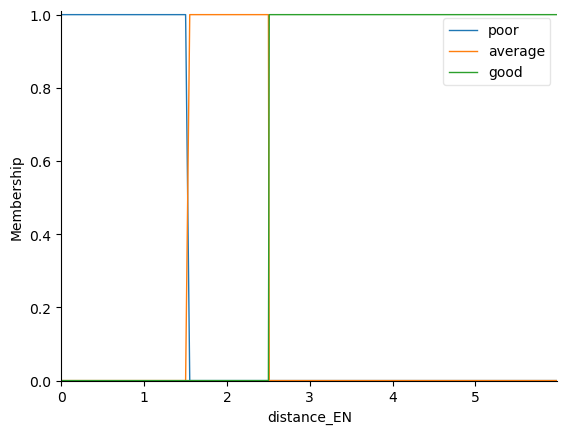

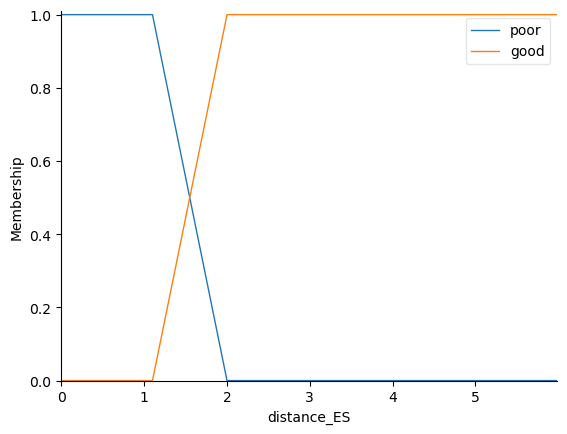

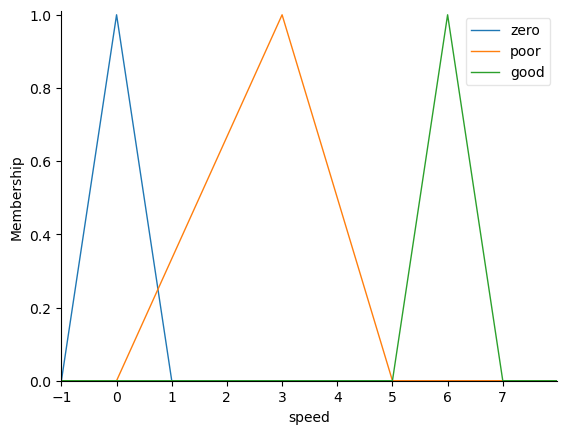

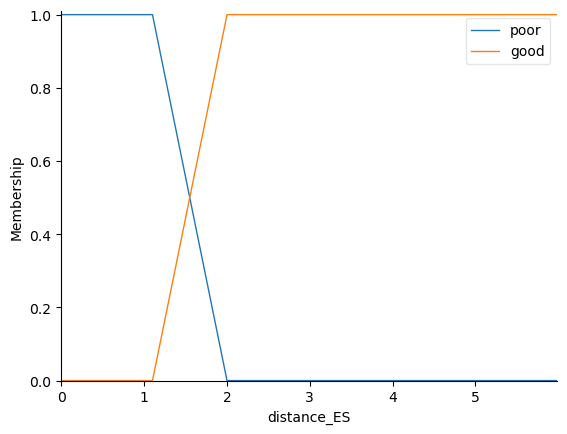

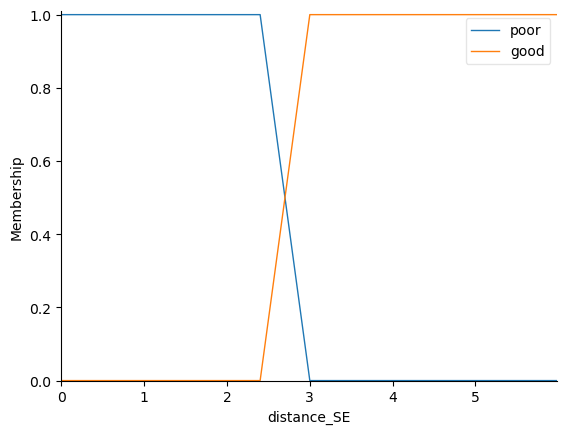

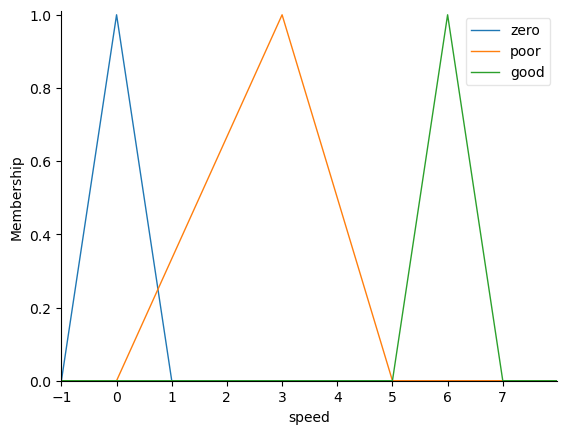

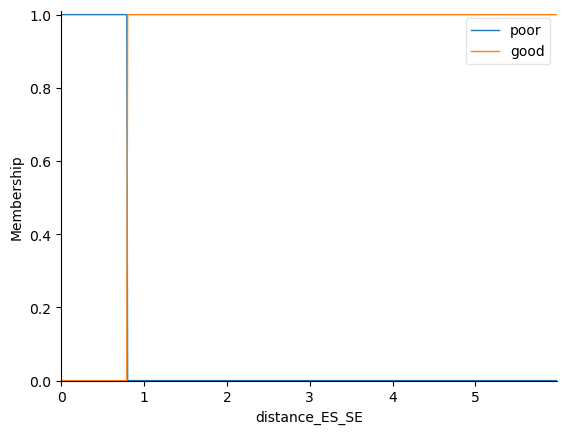

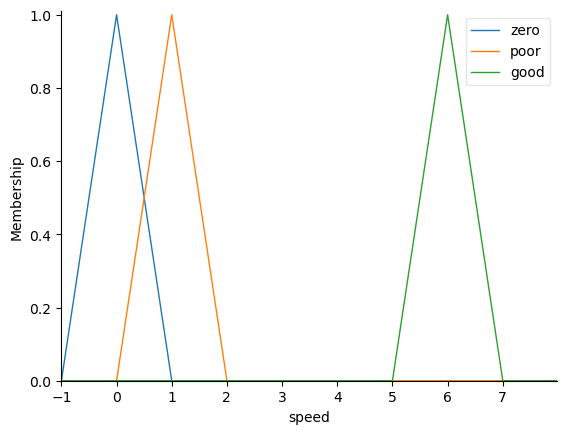

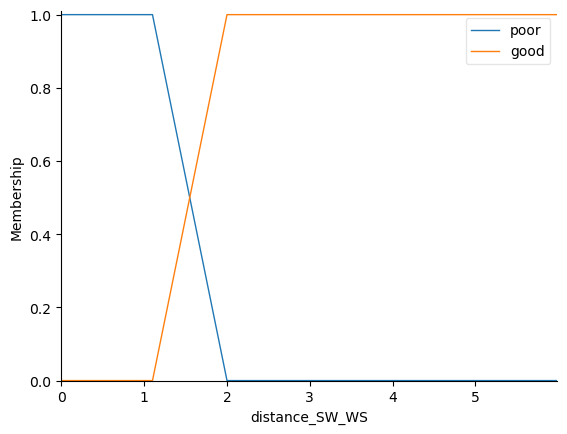

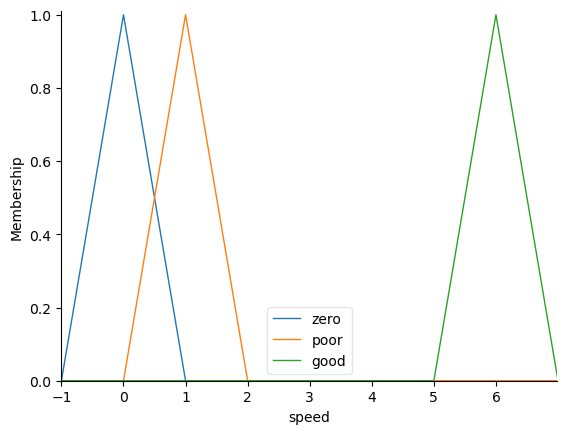

In [45]:
#continue reading and printing values from proximity sensors
distances = dict()
detection_states = dict()

for sensor_name, sensor_handle in zip(proximity_sensors,proximity_sensors_handles):
        err_code,detectionState,detectedPoint,detectedObjectHandle,detectedSurfaceNormalVector=vrep.simxReadProximitySensor(clientID,sensor_handle,vrep.simx_opmode_buffer)
        distances[sensor_name] = np.linalg.norm(detectedPoint)
        detection_states[sensor_name] = detectionState

zero_stage_sim = parallel_zero_stage()
first_stage_sim = parallel_first_stage()
second_stage_sim = parallel_second_stage()
third_stage_sim = parallel_third_stage()

current_stage = 0
t = time.time()
while (time.time()-t)<100: 
    for sensor_name, sensor_handle in zip(proximity_sensors,proximity_sensors_handles):
        err_code,detectionState,detectedPoint,detectedObjectHandle,detectedSurfaceNormalVector=vrep.simxReadProximitySensor(clientID,sensor_handle,vrep.simx_opmode_buffer)
        distances[sensor_name] = np.linalg.norm(detectedPoint)
        detection_states[sensor_name] = detectionState

        match current_stage:
            case 0:
                zero_stage_sim.input['distance_ES'] = distances['ES']
                zero_stage_sim.input['distance_EN'] = distances['EN']

                zero_stage_sim.compute()

                speed = zero_stage_sim.output['speed']
                if speed < 3:
                    tank.forward(0)
                    current_stage += 1
                else:
                    tank.forward(speed)
            case 1:
                first_stage_sim.input['distance_ES'] = distances['ES']
                first_stage_sim.input['distance_SE'] = distances['SE']

                first_stage_sim.compute()

                new_tank_speed = first_stage_sim.output['speed']
                if new_tank_speed < 1:
                    tank.forward(0)
                    current_stage += 1
                else:
                    tank.forward(new_tank_speed)
            case 2:
                distance_input = min(distances['ES'], distances['SE'])
                second_stage_sim.input['distance_ES_SE'] = distance_input
                second_stage_sim.compute()

                new_tank_speed = second_stage_sim.output['speed']
                if new_tank_speed < 1:
                    tank.forward(0)
                    current_stage += 1
                else:
                    tank.leftvelocity = -new_tank_speed
                    tank.rightvelocity = -new_tank_speed / 6
                    tank.setVelocity()
            case 3:
                distance_input = min(distances['SW'], distances['WS'])
                third_stage_sim.input['distance_SW_WS'] = distance_input
                third_stage_sim.compute()

                new_tank_speed = third_stage_sim.output['speed']
                if new_tank_speed < 1:
                    tank.forward(0)
                    current_stage = -1 
                else:
                    tank.leftvelocity = -new_tank_speed / (8/3)
                    tank.rightvelocity = -new_tank_speed
                    tank.setVelocity()
    if current_stage == -1:
        print("Reached the end of the parallel stages.")
        break
